<a href="https://colab.research.google.com/github/shyamgadhiya/ML-DL-Tasks/blob/main/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Diabetes Detection

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("diabetes_prediction_dataset.csv")


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df.shape

(100000, 9)

The dataset includes 2 categorical features, gender and smoking_history, alongside 3 float variables: age, bmi, and HbA1c_level. Additionally, there are 4 integer columns: hypertension, heart_disease, blood_glucose_level, and the diabetes target.

In [ ]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


As above described especially in the `bmi` variable, the maximum value of 95.69 is far above the normal range and may indicate an outlier. Similarly, the `blood_glucose_level` reaching up to 300 shows that some individuals have very high glucose levels. In addition, the mean of `diabetes` being 0.085 indicates that approximately 8.5% of the individuals in the dataset have diabetes.

**Checking for Null Values in Dataset**

In [ ]:
df.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [ ]:
duplicated_count = df.duplicated().sum()
duplicated_rows = df[df.duplicated()]
print(f"Total number of duplicated rows in the dataset: {duplicated_count}")

Total number of duplicated rows in the dataset: 3854


In [ ]:
df = df.drop_duplicates()

In [ ]:
df[df["gender"] == "Other"]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
12669,Other,10.0,0,0,not current,14.09,5.0,140,0
14838,Other,19.0,0,0,No Info,27.32,5.7,158,0
16702,Other,39.0,0,0,not current,31.24,6.2,85,0
18691,Other,10.0,0,0,not current,16.59,6.1,160,0
23266,Other,23.0,0,0,No Info,24.23,6.1,140,0
31985,Other,53.0,0,0,No Info,27.32,6.6,160,0
33805,Other,45.0,0,0,never,27.32,4.0,159,0
34929,Other,47.0,0,0,never,36.76,6.6,90,0
35006,Other,47.0,0,0,never,36.76,3.5,200,0
40337,Other,18.0,0,0,not current,30.19,6.1,90,0


In [ ]:
df = df[df['gender'] != 'Other']

Drop Rows that consist Other as Gender because there are no positive diabetes cases.

##**Box plot Analysis for Detecting Outliers in feature set.**

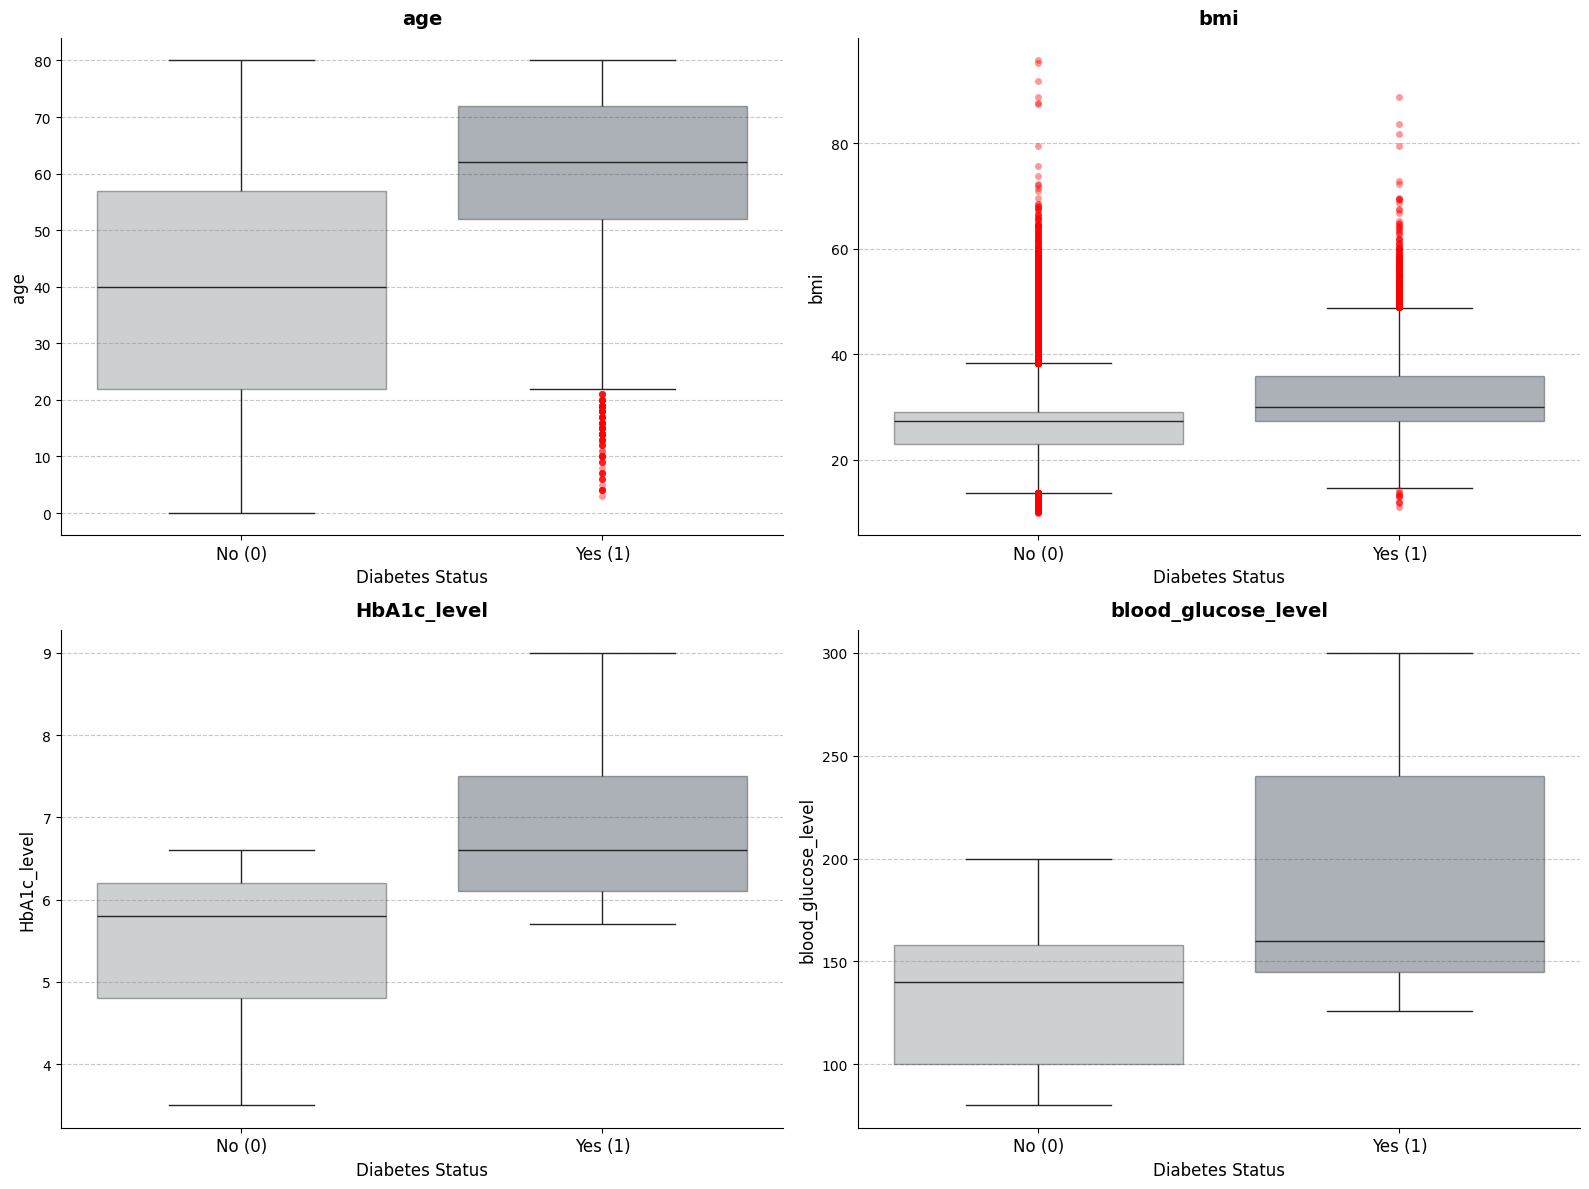

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

target_num_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]

# 1. Define custom properties to make outliers pop and mute the normal data
red_outliers = dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.4, markeredgecolor='none')
muted_boxes = dict(alpha=0.4)

# 2. Set up a 2x2 grid for the 4 plots
plt.figure(figsize=(16, 12))

for i, num_col in enumerate(target_num_cols, 1):
    # Creates a subplot layout: 2 rows, 2 columns
    plt.subplot(2, 2, i)

    # Generate the boxplot split by the target variable (diabetes)
    sns.boxplot(
        x="diabetes",
        y=num_col,
        hue="diabetes",
        data=df,
        palette=["#7f8c8d", "#2c3e50"],  # Muted grays/blues to let the red stand out
        flierprops=red_outliers,         # Apply bright red, semi-transparent outliers
        boxprops=muted_boxes,            # Fade the main boxes
        legend=False
    )

    # Customizing the look
    plt.title(f"{num_col}", fontsize=14, pad=10, fontweight='bold')
    plt.xticks(ticks=[0, 1], labels=["No (0)", "Yes (1)"], fontsize=12)
    plt.xlabel("Diabetes Status", fontsize=12)
    plt.ylabel(num_col, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Adds clean gridlines to easily spot outlier values

    # Remove top and right borders for a cleaner look
    sns.despine()

# 3. Prevent overlapping text and render
plt.tight_layout()
plt.show()

* Age Outliers: For diabetic patients (1), there is a tail of outliers going down toward 0. Statistically, these are outliers, but biologically, this represents juvenile/Type 1 diabetes. These are likely real, valid data points.

* BMI Outliers: Both groups have a massive, dense cluster of high-value outliers (ranging from 40 to nearly 100). This indicates that your BMI data is heavily right-skewed.

##**Handeling Outliers by Capping Method (replacing the extreme values with the Upper limit).**

In [ ]:
# Calculate IQR for BMI
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter and count
bmi_outliers = df[(df['bmi'] < lower_bound) | (df['bmi'] > upper_bound)]
print(f"Total BMI outliers: {len(bmi_outliers)}")
print(f"Percentage of dataset: {len(bmi_outliers) / len(df) * 100:.2f}%")

Total BMI outliers: 5354
Percentage of dataset: 5.57%


In [ ]:
# Cap the extreme upper outliers at the 99th percentile
upper_limit = df['bmi'].quantile(0.99)
df['bmi'] = np.where(df['bmi'] > upper_limit, upper_limit, df['bmi'])

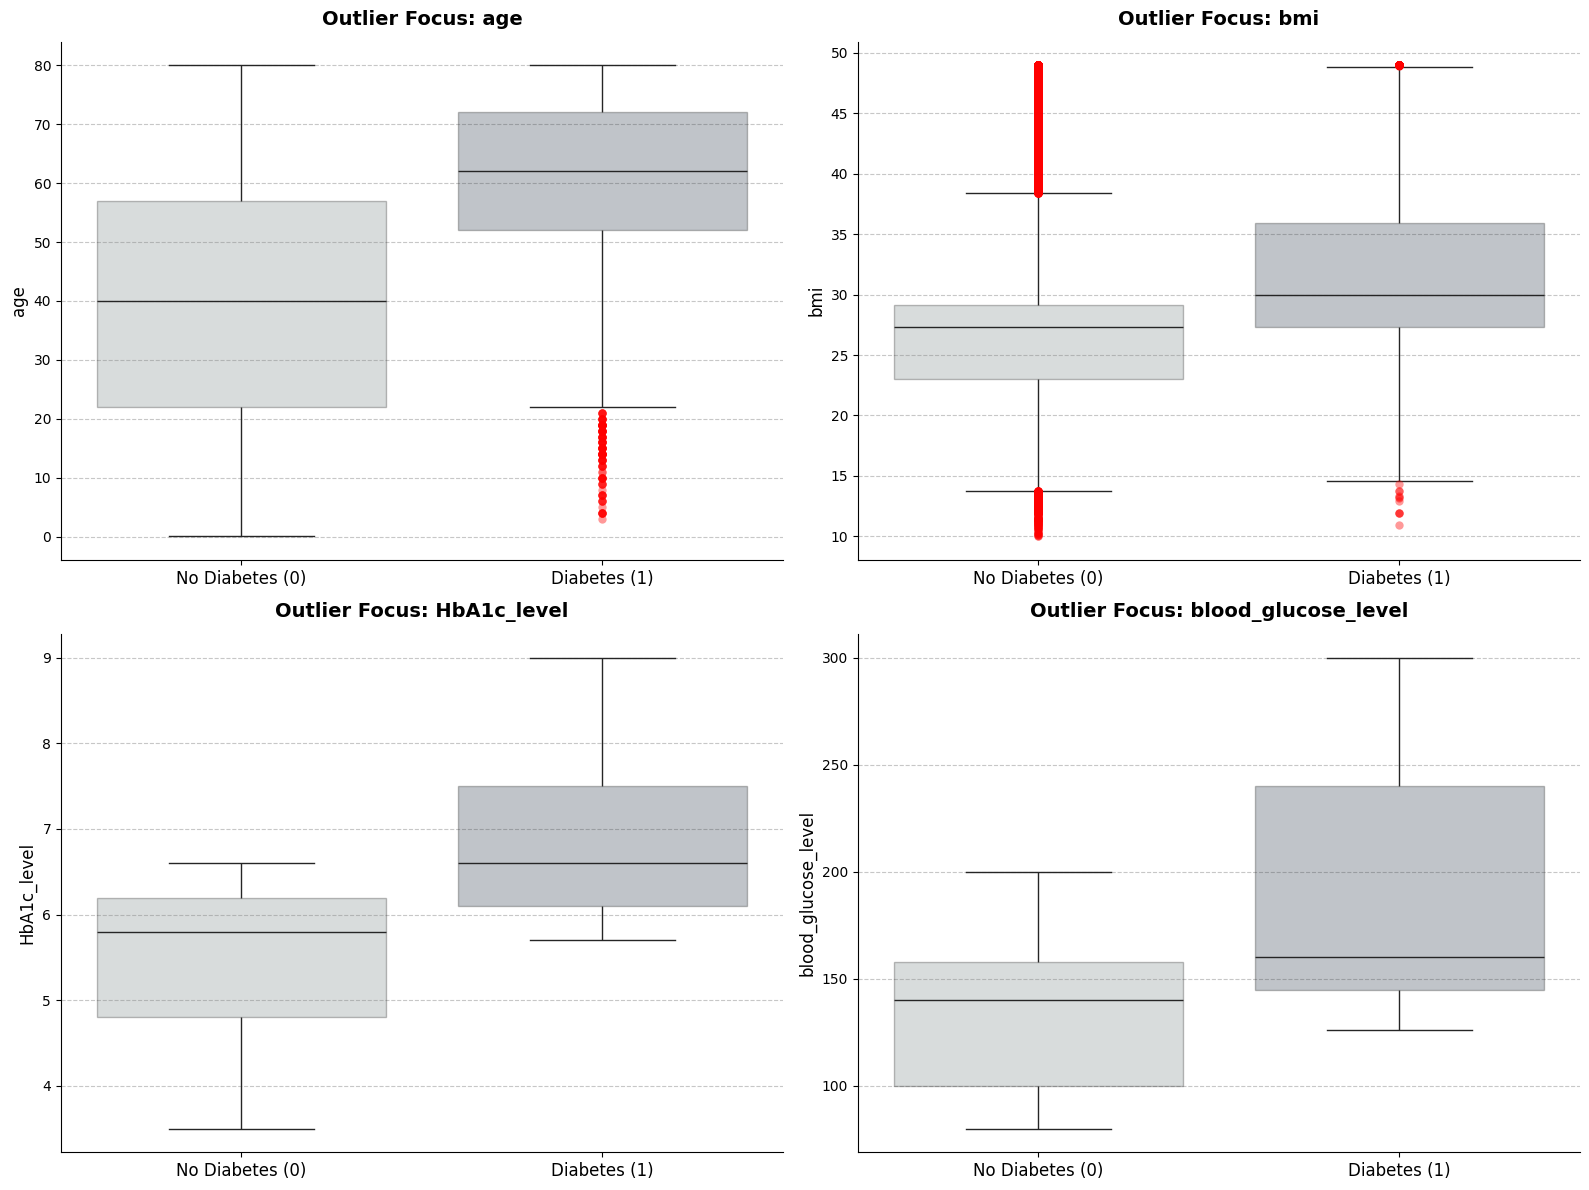

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

target_num_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

# 1. Isolate and aggressively style the outliers (bright red, slightly transparent)
red_outliers = dict(marker='o', markerfacecolor='red', markersize=6,
                    alpha=0.4, markeredgecolor='none')

# 2. Mute the normal data boxes (fade them out so outliers stand out)
muted_boxes = dict(alpha=0.3)

for i, num_col in enumerate(target_num_cols):
    sns.boxplot(
        data=df,
        x="diabetes",
        y=num_col,
        hue="diabetes",
        palette=["#7f8c8d", "#2c3e50"], # Muted grays/blues for the normal distributions
        flierprops=red_outliers,        # Inject the custom red outliers
        boxprops=muted_boxes,           # Inject the faded box style
        legend=False,
        ax=axes[i]
    )

    # Clean up the styling
    axes[i].set_title(f"Outlier Focus: {num_col}", fontsize=14, fontweight='bold', pad=12)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No Diabetes (0)", "Diabetes (1)"], fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(num_col, fontsize=12)

    # Gridlines help trace the exact value of the red outliers to the y-axis
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

sns.despine()
plt.tight_layout()
plt.show()

**Correlation Matrix and Heatmap Analysis to check Correlation and Multicollinearity between the Features.**

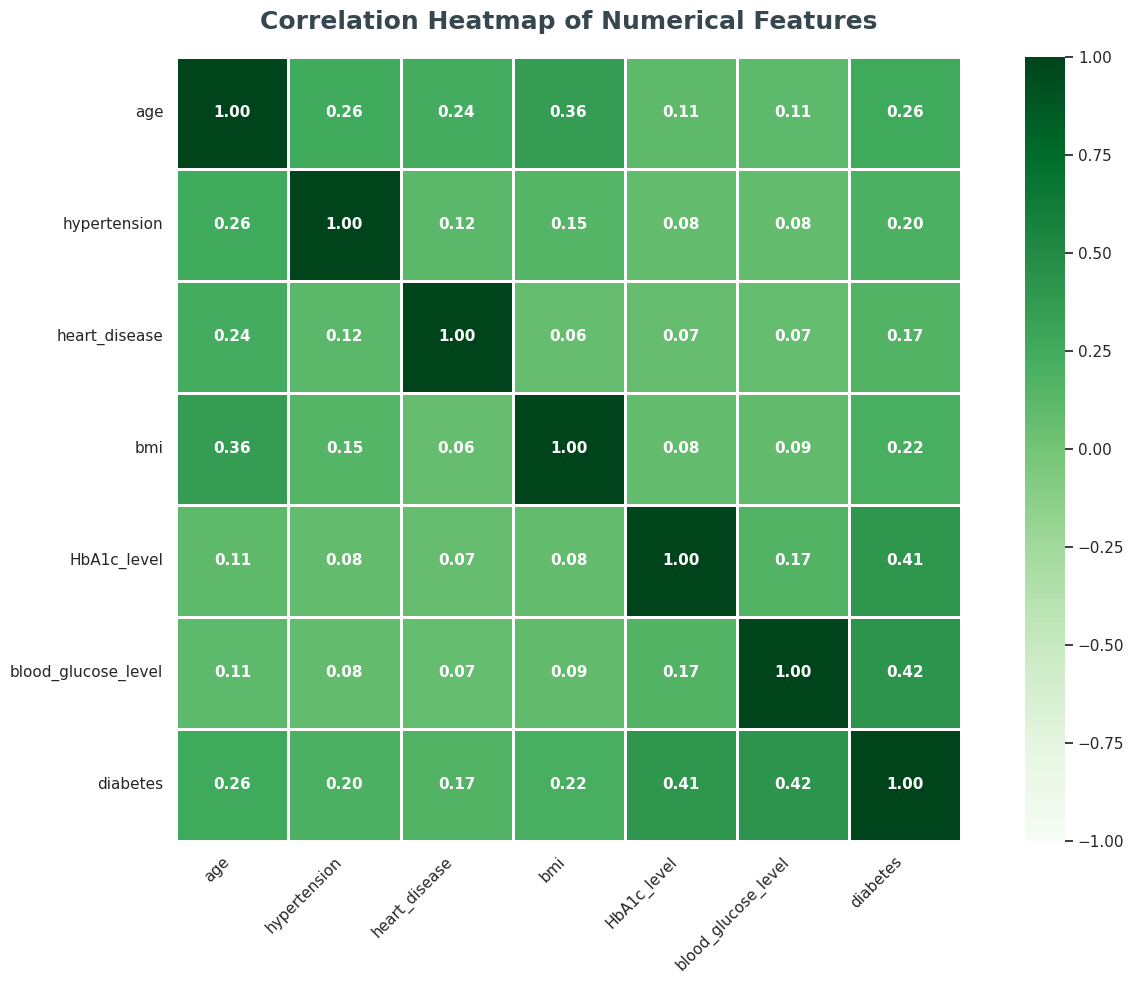

In [ ]:
numeric_df = df.select_dtypes(include = ["int64","float64"])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(14,10))
sns.set_theme(style= "white")
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="Greens",vmin=-1,
           vmax=1,linewidths=1,linecolor="white",square=True,annot_kws={"size":11,"weight":"bold"})
plt.title("Correlation Heatmap of Numerical Features",fontsize=18,fontweight="bold",color='#37474F', pad=20)
plt.xticks(rotation=45,ha="right",fontsize=11)
plt.yticks(rotation = 0,fontsize=11)
plt.tight_layout()
plt.show()

**Based on these HeatMap Most Important Predictors for Diabetes**

* All the correlations are positive, meaning as these factors increase, the likelihood of diabetes also increases.

* Dataset does not have severe multicollinearity.

* Primary Drivers: blood_glucose_level (0.42) and HbA1c_level (0.41) have the strongest correlations with diabetes. This makes perfect medical sense, as these are the primary biological markers used to diagnose the condition. These will be the most important features for your machine learning model.

* Secondary Drivers: age (0.26) and bmi (0.22) show a moderate positive correlation.

* Weakest Drivers: hypertension (0.20) and heart_disease (0.17) have the lowest correlation with diabetes in this dataset, though they still show a positive relationship.

##**Feature Imbalance Check**

/tmp/ipykernel_12518/3827092508.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


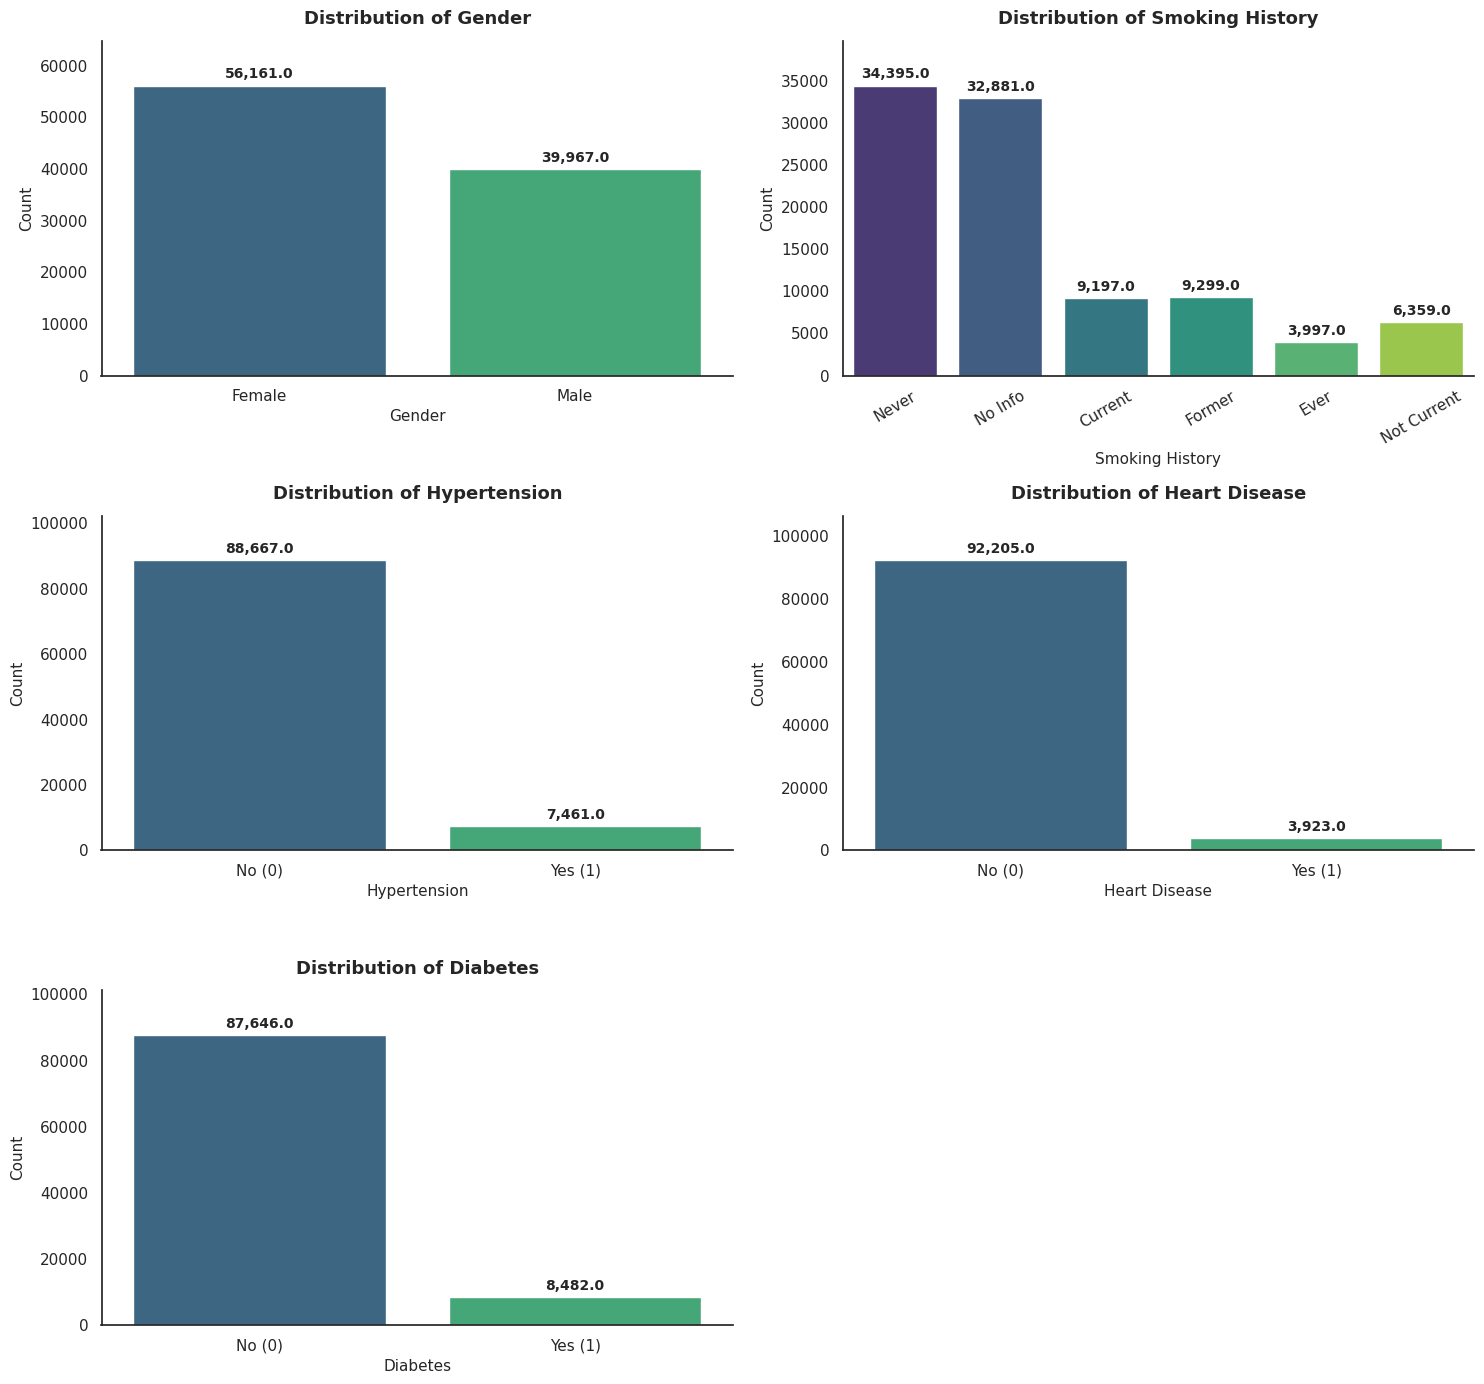

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = ["gender", "smoking_history", "hypertension", "heart_disease", "diabetes"]
binary_cols = ["hypertension", "heart_disease", "diabetes"]

# Human-readable title mapping
title_map = {
    "gender": "Gender",
    "smoking_history": "Smoking History",
    "hypertension": "Hypertension",
    "heart_disease": "Heart Disease",
    "diabetes": "Diabetes"
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]

    # 1. Plot countplot
    sns.countplot(
        data=df,
        x=col,
        hue=col,
        palette='viridis',
        legend=False,
        ax=ax
    )

    # 2. Polished Titles & Axis Labels
    display_name = title_map.get(col, col)
    ax.set_title(f'Distribution of {display_name}', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel(display_name, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)

    # 3. Handle X-Tick Formatting & Labels
    if col in binary_cols:
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['No (0)', 'Yes (1)'])
        ax.tick_params(axis='x', rotation=0) # Keep short labels horizontal
    elif col == "smoking_history":
        # Format snake_case to Title Case (e.g. 'not_current' -> 'Not Current')
        labels = [text.get_text().replace('_', ' ').title() for text in ax.get_xticklabels()]
        ax.set_xticklabels(labels)
        ax.tick_params(axis='x', rotation=30) # Rotate only long category names
    else:
        ax.tick_params(axis='x', rotation=0)

    # 4. Add Bar Labels (Formats counts with thousands separators, e.g., 90,000)
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,}', padding=3, fontsize=10, fontweight='bold')

    # 5. Expand Y-axis upper limit slightly so top labels don't get cut off
    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

# Remove unused axes (the 6th subplot)
for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

# 6. Overall Aesthetics
sns.despine() # Remove top and right borders
plt.tight_layout()
plt.show()

Count plots highlight a severe class imbalance in our target variable diabetes as well as in hypertension and heart disease, where healthy individuals vastly outnumber the diagnosed patients.

##**Bivariate Analysis on the important features**

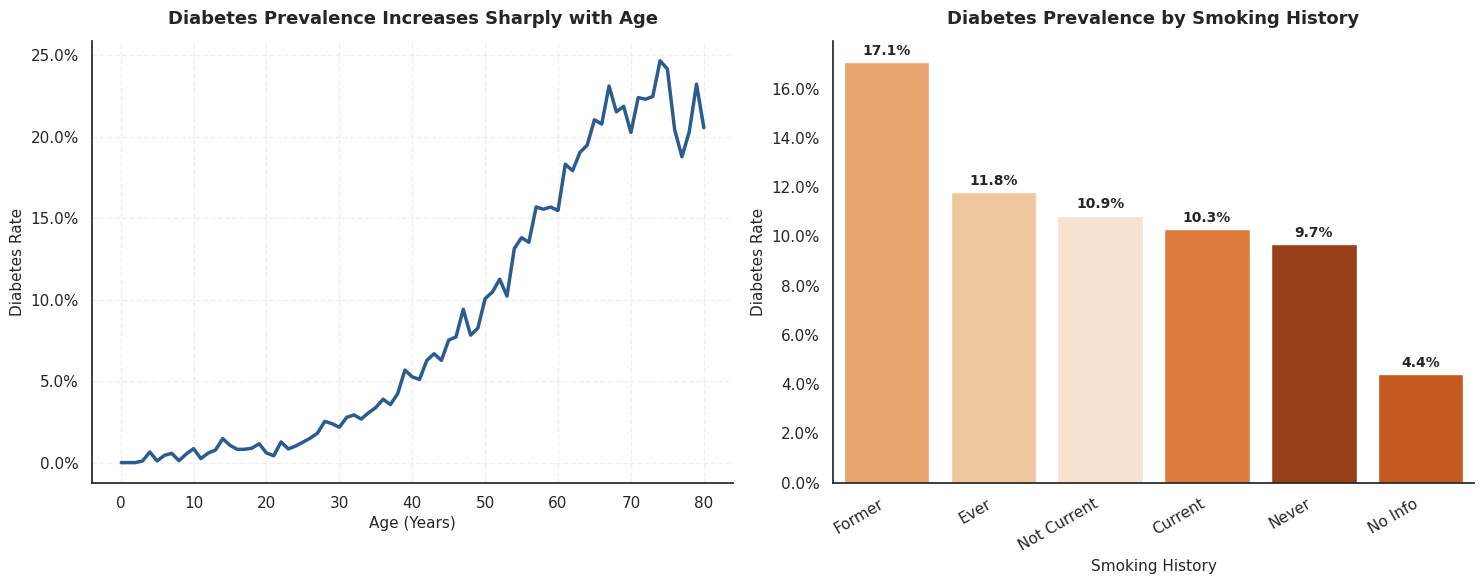

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---------------------------------------------------------
# 1. Diabetes Prevalence by Age (Continuous Line Chart)
# ---------------------------------------------------------
sns.lineplot(
    data=df,
    x="age",
    y="diabetes",
    color="#2b5c8f",
    linewidth=2.5,
    errorbar=None,  # Removes noisy shadow for a clean trend line
    ax=axes[0]
)

axes[0].set_title("Diabetes Prevalence Increases Sharply with Age", fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel("Age (Years)", fontsize=11)
axes[0].set_ylabel("Diabetes Rate", fontsize=11)

# Format Y-axis as Percentage and add light grid lines
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].grid(True, linestyle='--', alpha=0.3)

# ---------------------------------------------------------
# 2. Diabetes Prevalence by Smoking History (Sorted Bar Plot)
# ---------------------------------------------------------
# Calculate mean rate per category to sort bars from highest to lowest
smoking_order = df.groupby('smoking_history')['diabetes'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x="smoking_history",
    y="diabetes",
    order=smoking_order,  # Sort bars by prevalence
    hue="smoking_history",
    palette="Oranges_r",
    errorbar=None,
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Diabetes Prevalence by Smoking History", fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel("Smoking History", fontsize=11)
axes[1].set_ylabel("Diabetes Rate", fontsize=11)

# Format Y-axis as Percentage
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Format and capitalize X-axis tick labels
clean_labels = [str(label).replace('_', ' ').title() for label in smoking_order]
axes[1].set_xticks(range(len(clean_labels)))
axes[1].set_xticklabels(clean_labels, rotation=30, ha='right')

# Add exact percentage labels on top of each bar
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='{:.1%}', padding=3, fontsize=10, fontweight='bold')

# ---------------------------------------------------------
# Aesthetics & Clean Borders
# ---------------------------------------------------------
sns.despine()  # Removes top and right box borders
plt.tight_layout()
plt.show()

 * We can see a clear and steady increase in diabetes risk with age.
 * There is a significant jump in risk especially after the age of 35, and the rate peaks after age of 50.
 * Looking at the smoking history, as expected, the lowest diabetes rate is among those who have never smoked and No info.
 * However, what really caught my attention here is that the highest prevalence is not among current smokers, but among past(former) smokers.

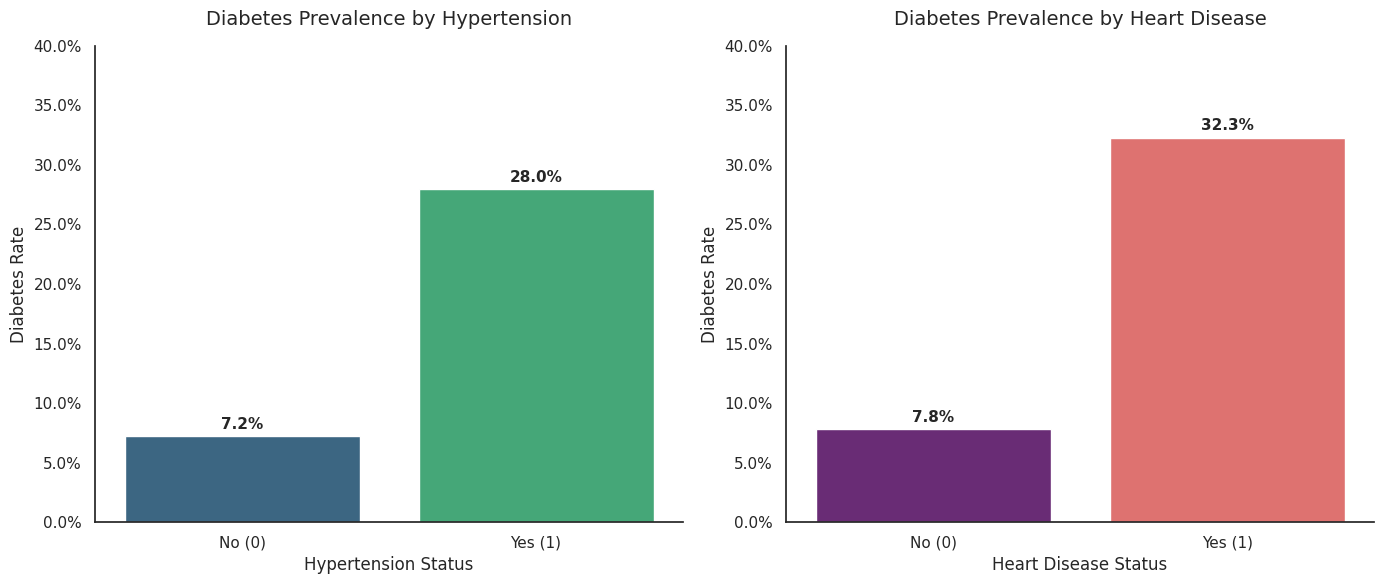

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Set up the figure with standard sizing
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------------------------------------------------------
# Plot 1: Hypertension
# ---------------------------------------------------------
sns.barplot(
    data=df,
    x="hypertension",
    y="diabetes",
    hue="hypertension",
    errorbar=None,
    palette="viridis",
    legend=False, # Removed redundant legend
    ax=axes[0]
)

axes[0].set_title("Diabetes Prevalence by Hypertension", fontsize=14, pad=15)
axes[0].set_xlabel("Hypertension Status", fontsize=12)
axes[0].set_ylabel("Diabetes Rate", fontsize=12)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No (0)", "Yes (1)"])

# Format Y-axis as percentage and standardize the upper limit
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_ylim(0, 0.40)

# Add exact percentage labels on top of the bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='{:.1%}', padding=3, fontsize=11, fontweight='bold')

# ---------------------------------------------------------
# Plot 2: Heart Disease
# ---------------------------------------------------------
sns.barplot(
    data=df,
    x="heart_disease",
    y="diabetes",
    hue="heart_disease",
    errorbar=None,
    palette="magma",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Diabetes Prevalence by Heart Disease", fontsize=14, pad=15)
axes[1].set_xlabel("Heart Disease Status", fontsize=12)
axes[1].set_ylabel("Diabetes Rate", fontsize=12)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["No (0)", "Yes (1)"])

# Format Y-axis as percentage and match the upper limit of the first plot
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_ylim(0, 0.40)

# Add exact percentage labels on top of the bars
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='{:.1%}', padding=3, fontsize=11, fontweight='bold')

# ---------------------------------------------------------
# Final Aesthetics
# ---------------------------------------------------------
# Remove top and right borders from both subplots
sns.despine()

plt.tight_layout()
plt.show()

**The Impact of Hypertension**
* Without Hypertension (0): The baseline diabetes rate for people without hypertension is very low, hovering around 7.2% (0.07 on the y-axis).

* With Hypertension (1): For patients who do have hypertension, the diabetes rate jumps significantly to almost 28%.

* Takeaway: A person with hypertension is roughly four times more likely to have diabetes than someone without it.

**The Impact of Heart Disease**
* Without Heart Disease (0): Similar to the previous graph, people without heart disease have a low baseline diabetes rate of roughly 7-8%.

* With Heart Disease (1): For patients with heart disease, the diabetes rate spikes dramatically to over 32%.

* Takeaway: Having heart disease is a massive risk indicator in this dataset. Patients with heart disease are over four times more likely to be diabetic compared to the rest of the population.

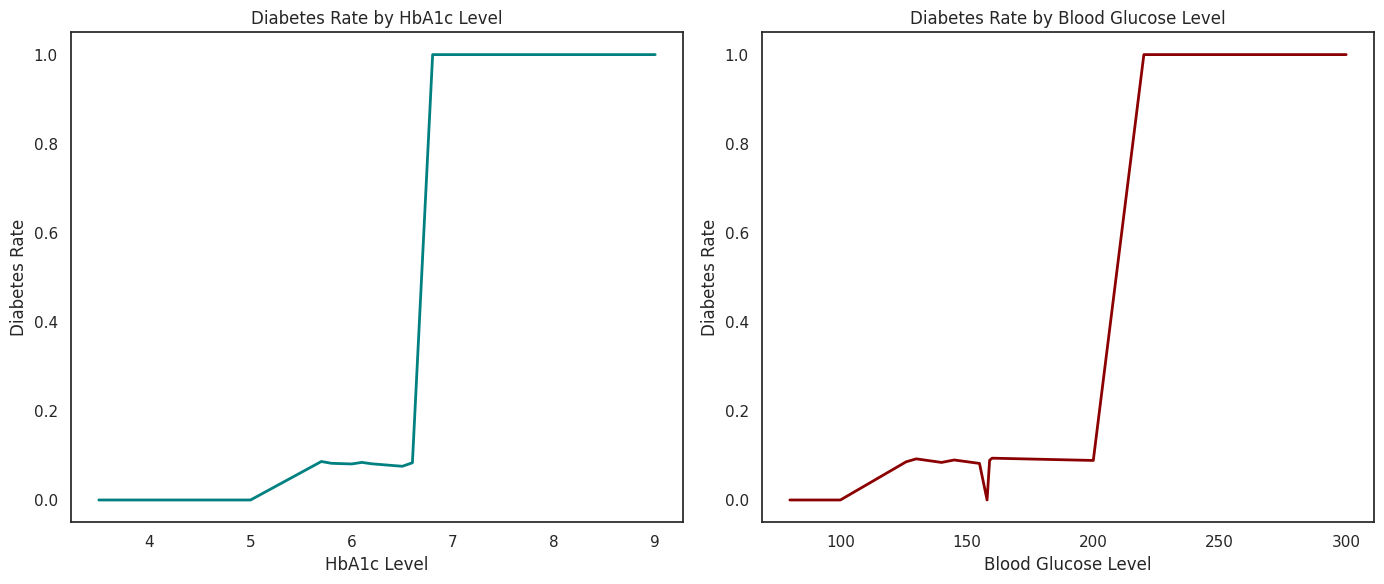

In [ ]:
fig,axes = plt.subplots(1,2,figsize=(14,6))
sns.lineplot(data=df,x="HbA1c_level",y="diabetes",color="teal",linewidth=2,errorbar=None,ax=axes[0])
axes[0].set_title("Diabetes Rate by HbA1c Level")
axes[0].set_xlabel("HbA1c Level")
axes[0].set_ylabel("Diabetes Rate")

sns.lineplot(data=df,x="blood_glucose_level",y="diabetes",color="darkred",linewidth=2,errorbar=None,ax=axes[1])
axes[1].set_title("Diabetes Rate by Blood Glucose Level")
axes[1].set_xlabel("Blood Glucose Level")
axes[1].set_ylabel("Diabetes Rate")

plt.tight_layout()
plt.show()

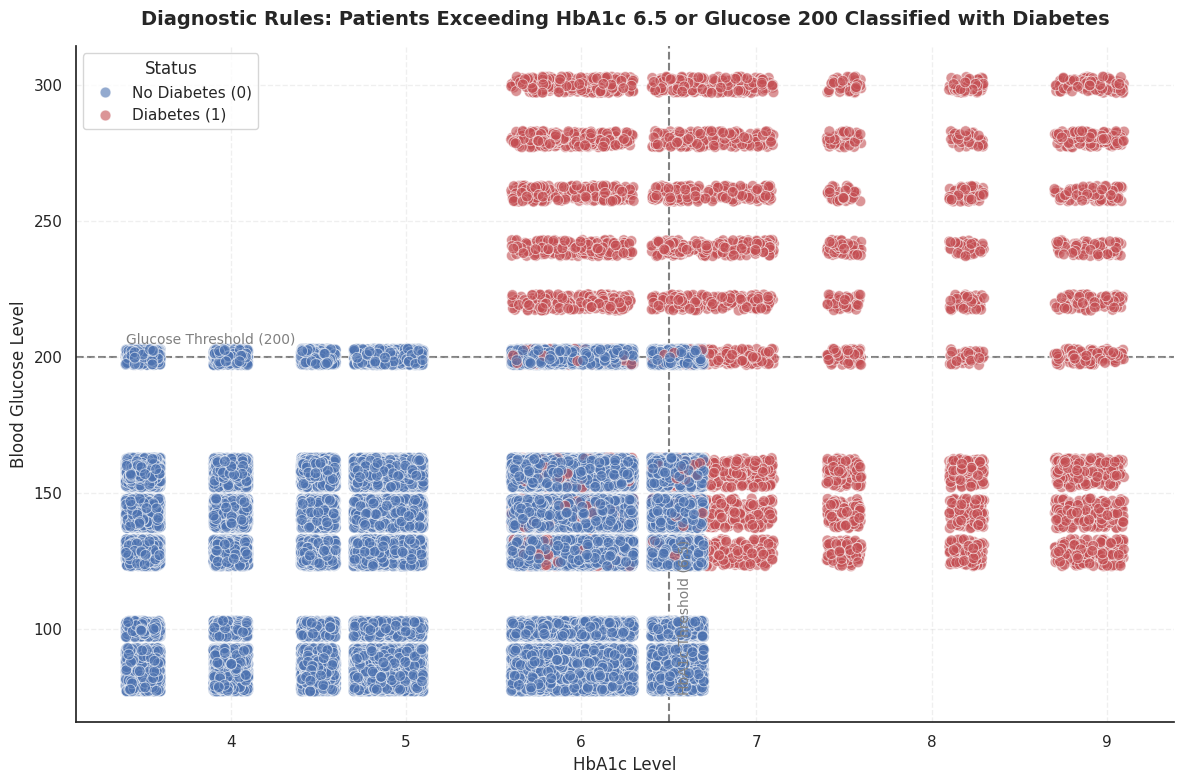

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Create a temporary copy to add "jitter" (noise) without altering your actual data
# This breaks up the grid pattern so you can see where the dots are truly densely packed
viz_df = df.copy()
viz_df['HbA1c_jitter'] = viz_df['HbA1c_level'] + np.random.uniform(-0.1, 0.1, size=len(viz_df))
viz_df['Glucose_jitter'] = viz_df['blood_glucose_level'] + np.random.uniform(-3, 3, size=len(viz_df))

plt.figure(figsize=(12, 8))

# 2. Scatter plot using the jittered data and a slightly softer, modern color palette
scatter = sns.scatterplot(
    data=viz_df,
    x='HbA1c_jitter',
    y='Glucose_jitter',
    hue='diabetes',
    palette={0: '#4C72B0', 1: '#C44E52'}, # Softer Blue and Red
    alpha=0.6,
    edgecolor='white',
    s=60
)

# 3. Draw explicit decision boundary lines
plt.axvline(x=6.5, color='gray', linestyle='--', linewidth=1.5, zorder=0)
plt.axhline(y=200, color='gray', linestyle='--', linewidth=1.5, zorder=0)

# Add small text annotations for the threshold lines
plt.text(6.55, viz_df['Glucose_jitter'].min(), 'HbA1c Threshold (6.5)', color='gray', fontsize=10, rotation=90)
plt.text(viz_df['HbA1c_jitter'].min(), 205, 'Glucose Threshold (200)', color='gray', fontsize=10)

# 4. Upgrade overall aesthetics
# Use a takeaway-driven title rather than a descriptive one
plt.title('Diagnostic Rules: Patients Exceeding HbA1c 6.5 or Glucose 200 Classified with Diabetes',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('HbA1c Level', fontsize=12)
plt.ylabel('Blood Glucose Level', fontsize=12)

# 5. Fix the legend bug
# Extract handles directly from seaborn to maintain correct color mapping
handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles=handles, labels=['No Diabetes (0)', 'Diabetes (1)'], title='Status', loc='upper left')

# Remove the top and right chart borders for a cleaner look
sns.despine()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

###**HbA1c Level (Left Plot):**

* Below 5.0: Diabetes rate is 0%.

* 5.0 to 6.6: Diabetes rate sits at a low baseline of ~8%–10%.

* Above ~6.6–6.7: The rate sharply jumps to 100% and remains flat at 1.0.

###**Blood Glucose Level (Right Plot):**

* Below 100 mg/dL: Diabetes rate is 0%.

* 100 to 200 mg/dL: Diabetes rate stays at a low baseline of ~8%–10% (with a brief drop down to 0% near 160 mg/dL).

* Above 200 mg/dL: The rate sharply spikes straight to 100%.

 * Based on the above chart we can determine that HbA1c Level  prevalence fluctuates slightly in the some ranges, it suddenly reaches absolute certainty once specific critical limits are crossed. Specifically, when the HbA1c level exceeds 6.5 and blood glucose passes the 200 mark, the positive diagnosis rate jumps directly to 100 percent. This entire picture shows me just how direct and definitive the relationship is between both clinical measurements and the presence of diabetes.

##**Model Development**

**Labeling the categorical features using One Hot Encoding.**

In [ ]:
df = pd.get_dummies(df , dtype="int" , drop_first = True)

In [ ]:
df.head(10)

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,0,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,1,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,1,1,0,0,0,0
5,20.0,0,0,27.32,6.6,85,0,0,0,0,0,1,0
6,44.0,0,0,19.31,6.5,200,1,0,0,0,0,1,0
7,79.0,0,0,23.86,5.7,85,0,0,0,0,0,0,0
8,42.0,0,0,33.64,4.8,145,0,1,0,0,0,1,0
9,32.0,0,0,27.32,5.0,100,0,0,0,0,0,1,0


**Splitting data into Train Test Split**

In [ ]:
X = df.drop(columns = "diabetes" , axis = 1)
y = df["diabetes"]

In [ ]:
X

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Male,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,1,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
99994,36.0,0,0,24.60,4.8,145,0,0,0,0,0,0
99996,2.0,0,0,17.37,6.5,100,0,0,0,0,0,0
99997,66.0,0,0,27.83,5.7,155,1,0,0,1,0,0
99998,24.0,0,0,35.42,4.0,100,0,0,0,0,1,0


In [ ]:
y.value_counts()

,count
diabetes,
0,87646
1,8482


#Logistic Regression without data imputation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , accuracy_score , confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X ,y , random_state = 42, test_size = 0.2)

In [ ]:
model = LogisticRegression( max_iter=10000)
model.fit(X_train ,y_train)

LogisticRegression(max_iter=10000)

In [ ]:
model.score(X_train,y_train)

0.9593898728251541

In [ ]:
model.score(X_test,y_test)

0.9574014355560179

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
cm = confusion_matrix(y_test,y_pred)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[17355   170]
 [  649  1052]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     17525
           1       0.86      0.62      0.72      1701

    accuracy                           0.96     19226
   macro avg       0.91      0.80      0.85     19226
weighted avg       0.95      0.96      0.95     19226



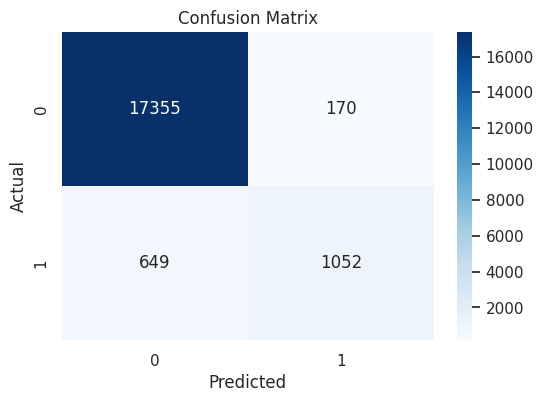

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Over Sampling Using SMOTE to handle Data Imbalance.**

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled , y_resampled = smote.fit_resample(X , y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled , y_resampled , random_state = 42, test_size = 0.2)

In [ ]:
model = LogisticRegression( max_iter=10000)
model.fit(X_train ,y_train)

LogisticRegression(max_iter=10000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
model.score(X_train,y_train)

0.9002802478731825

In [ ]:
model.score(X_test,y_test)

0.90096694144157

In [ ]:
cm = confusion_matrix(y_test,y_pred)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[15768  1697]
 [ 1775 15819]]
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     17465
           1       0.90      0.90      0.90     17594

    accuracy                           0.90     35059
   macro avg       0.90      0.90      0.90     35059
weighted avg       0.90      0.90      0.90     35059



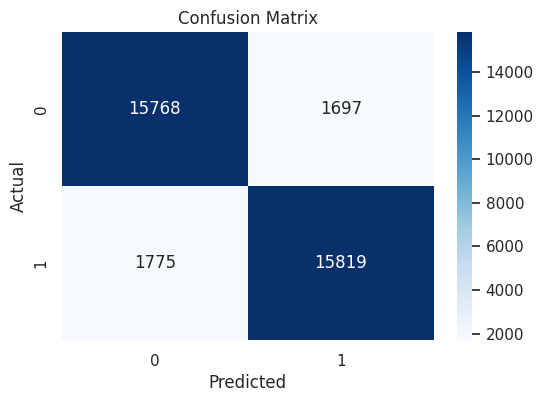

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    random_state=42,
    criterion = "entropy",
    max_depth = 8
)

In [ ]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=8, random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91     17465
           1       0.89      0.94      0.91     17594

    accuracy                           0.91     35059
   macro avg       0.91      0.91      0.91     35059
weighted avg       0.91      0.91      0.91     35059



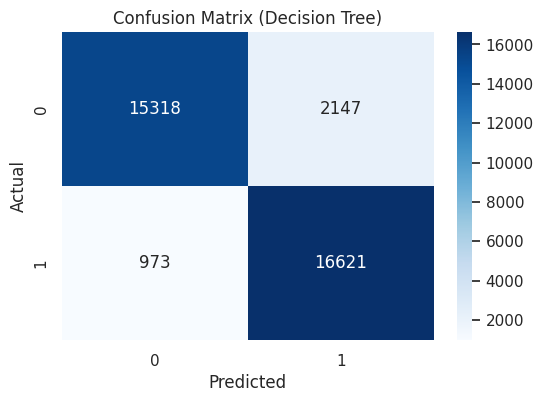

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Decision Tree)")

plt.show()

#Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=150,criterion="gini",max_depth=6,random_state=42,)

In [ ]:
rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=6, n_estimators=150, random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92     17465
           1       0.92      0.92      0.92     17594

    accuracy                           0.92     35059
   macro avg       0.92      0.92      0.92     35059
weighted avg       0.92      0.92      0.92     35059



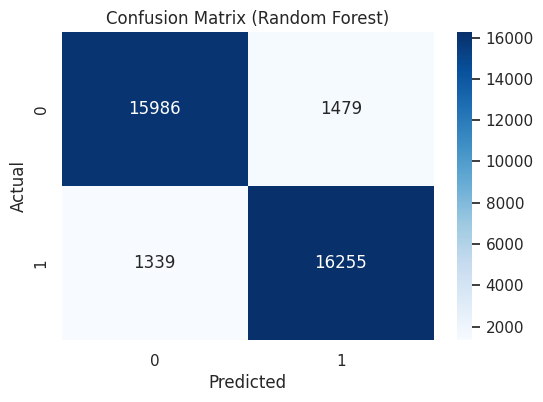

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest)")

plt.show()

**Finding important feature for Random Forest**

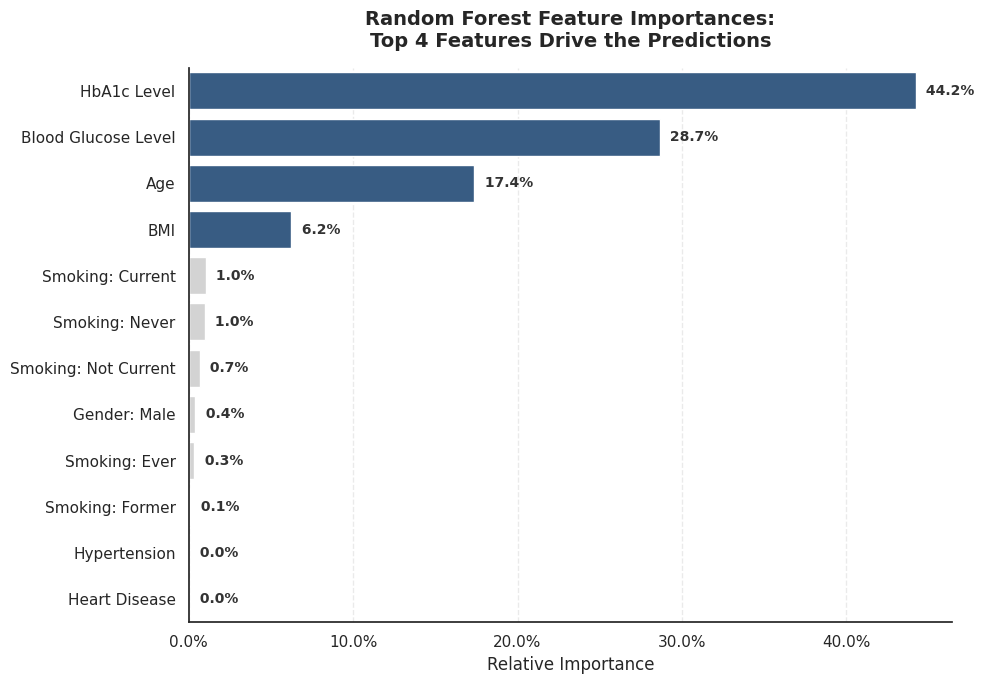

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 1. Sort the importances first and store them to avoid repeating code
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# 2. Clean up raw column names to make them human-readable
clean_labels = {
    'HbA1c_level': 'HbA1c Level',
    'blood_glucose_level': 'Blood Glucose Level',
    'age': 'Age',
    'bmi': 'BMI',
    'smoking_history_current': 'Smoking: Current',
    'smoking_history_never': 'Smoking: Never',
    'smoking_history_not current': 'Smoking: Not Current',
    'gender_Male': 'Gender: Male',
    'smoking_history_ever': 'Smoking: Ever',
    'smoking_history_former': 'Smoking: Former',
    'hypertension': 'Hypertension',
    'heart_disease': 'Heart Disease'
}
# Map the clean labels, fallback to title case if a column isn't in the dict
importances.index = importances.index.map(lambda x: clean_labels.get(x, x.replace('_', ' ').title()))

plt.figure(figsize=(10, 7))

# 3. Storytelling with Color: Highlight the top 4 features, fade the rest to gray
# Since the top 4 features do all the heavy lifting, we emphasize them visually.
colors = ['#2b5c8f' if i < 4 else '#d3d3d3' for i in range(len(importances))]

# Generate the bar plot
ax = sns.barplot(
    x=importances.values,
    y=importances.index,
    hue=importances.index, # Setting hue to y avoids Seaborn deprecation warnings
    palette=colors,
    legend=False
)

# 4. Refine Titles and Axis Labels
plt.title('Random Forest Feature Importances:\nTop 4 Features Drive the Predictions',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('') # Removed 'Feature' since it's obvious

# 5. Format X-axis and exact Bar Labels as Percentages
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for container in ax.containers:
    # Add exact percentage to the end of each bar (e.g., "43.5%")
    ax.bar_label(container, fmt=' {:.1%}', padding=4, fontsize=10, fontweight='bold', color='#333333')

# 6. Overall Aesthetics
plt.grid(axis='x', linestyle='--', alpha=0.4)
sns.despine() # Removes top and right borders

plt.tight_layout()
plt.show()

#XGBoost Model

In [ ]:
from xgboost import XGBClassifier

# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(random_state=42,max_depth = 9,learning_rate=0.1)

In [ ]:
# Fit the model on the training data
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test)

# Display the classification report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     17465
           1       0.99      0.95      0.97     17594

    accuracy                           0.97     35059
   macro avg       0.97      0.97      0.97     35059
weighted avg       0.97      0.97      0.97     35059



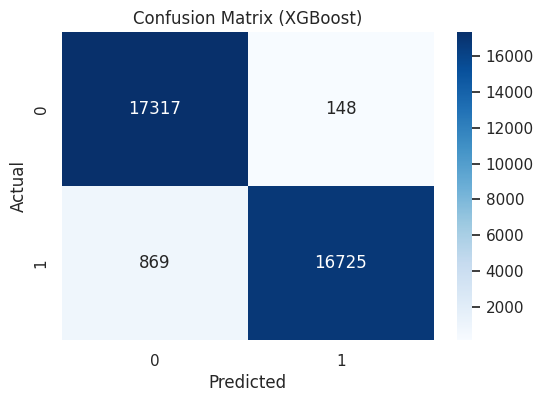

In [ ]:
# Display the confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (XGBoost)")

plt.show()

#Support Vector Classifier

In [ ]:
from sklearn.svm import SVC

# Initialize the Support Vector Classifier
svc_model = SVC(random_state=42)

# Fit the model to the training data
svc_model.fit(X_train, y_train)

SVC(random_state=42)

In [ ]:

# Make predictions on the test set
y_pred_svc = svc_model.predict(X_test)

# Print the classification report
print("Support Vector Classifier Performance:")
print(classification_report(y_test, y_pred_svc))

Support Vector Classifier Performance:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     17465
           1       0.88      0.92      0.90     17594

    accuracy                           0.90     35059
   macro avg       0.90      0.90      0.90     35059
weighted avg       0.90      0.90      0.90     35059



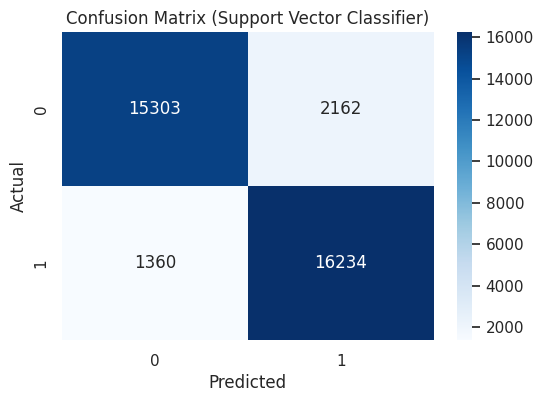

In [ ]:
# Display the confusion matrix
cm_svc = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(6,4))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Support Vector Classifier)")
plt.show()

## Classification Report Comparison

| Model | Accuracy | Precision (Class 1) | Recall (Class 1) | F1-Score (Class 1) |
| :--- | :---: | :---: | :---: | :---: |
| **Logistic Regression (with SMOTE)** | 0.90 | 0.90 | 0.90 | 0.90 |
| **Decision Tree** | 0.91 | 0.89 | 0.94 | 0.91 |
| **Random Forest** | 0.92 | 0.92 | 0.92 | 0.92 |
| **XGBoost** | **0.97** | **0.99** | **0.95** | **0.97** |
| **Support Vector Machine** | 0.90 | 0.88 | 0.92 | 0.90 |

---

## Evaluation Summary

Based on the updated evaluation metrics, here are the key takeaways from our modeling pipeline:

*   **XGBoost (Best Performer):** Continues to be the standout model, achieving an impressive accuracy of **97%**. It delivers exceptionally strong precision (**99%**), recall (**95%**), and F1-score (**97%**) for the positive class (diabetes), making it highly reliable at minimizing false positives while catching true cases.
*   **Random Forest:** Shows solid, improved performance with an accuracy of **92%** and perfectly balanced precision and recall for both classes. This corrects the previous observation where it was mistakenly mapped to the Decision Tree's metrics.
*   **Decision Tree:** Achieves an accuracy of **91%**, demonstrating a strong recall (**94%**) for the positive class, meaning it is aggressive at catching diabetic cases even if it compromises slightly on precision.
*   **Support Vector Machine(SVC):** Achieves an accuracy of **90%**, demonstrating a recall (**92%**) for the positive class but it takes more time for training the data beacuse dataset size is larger so instead of SVM we can use Logistic Regression.
*   **Logistic Regression:** Boosted by the **SMOTE oversampling** preprocessing step, it maintains a highly balanced **90%** across all metrics, proving that balancing the training data effectively stabilized its ability to handle severe class imbalance.

> **Final Conclusion:** Overall, **XGBoost** stands out as the most effective and robust model for this diabetes prediction task.

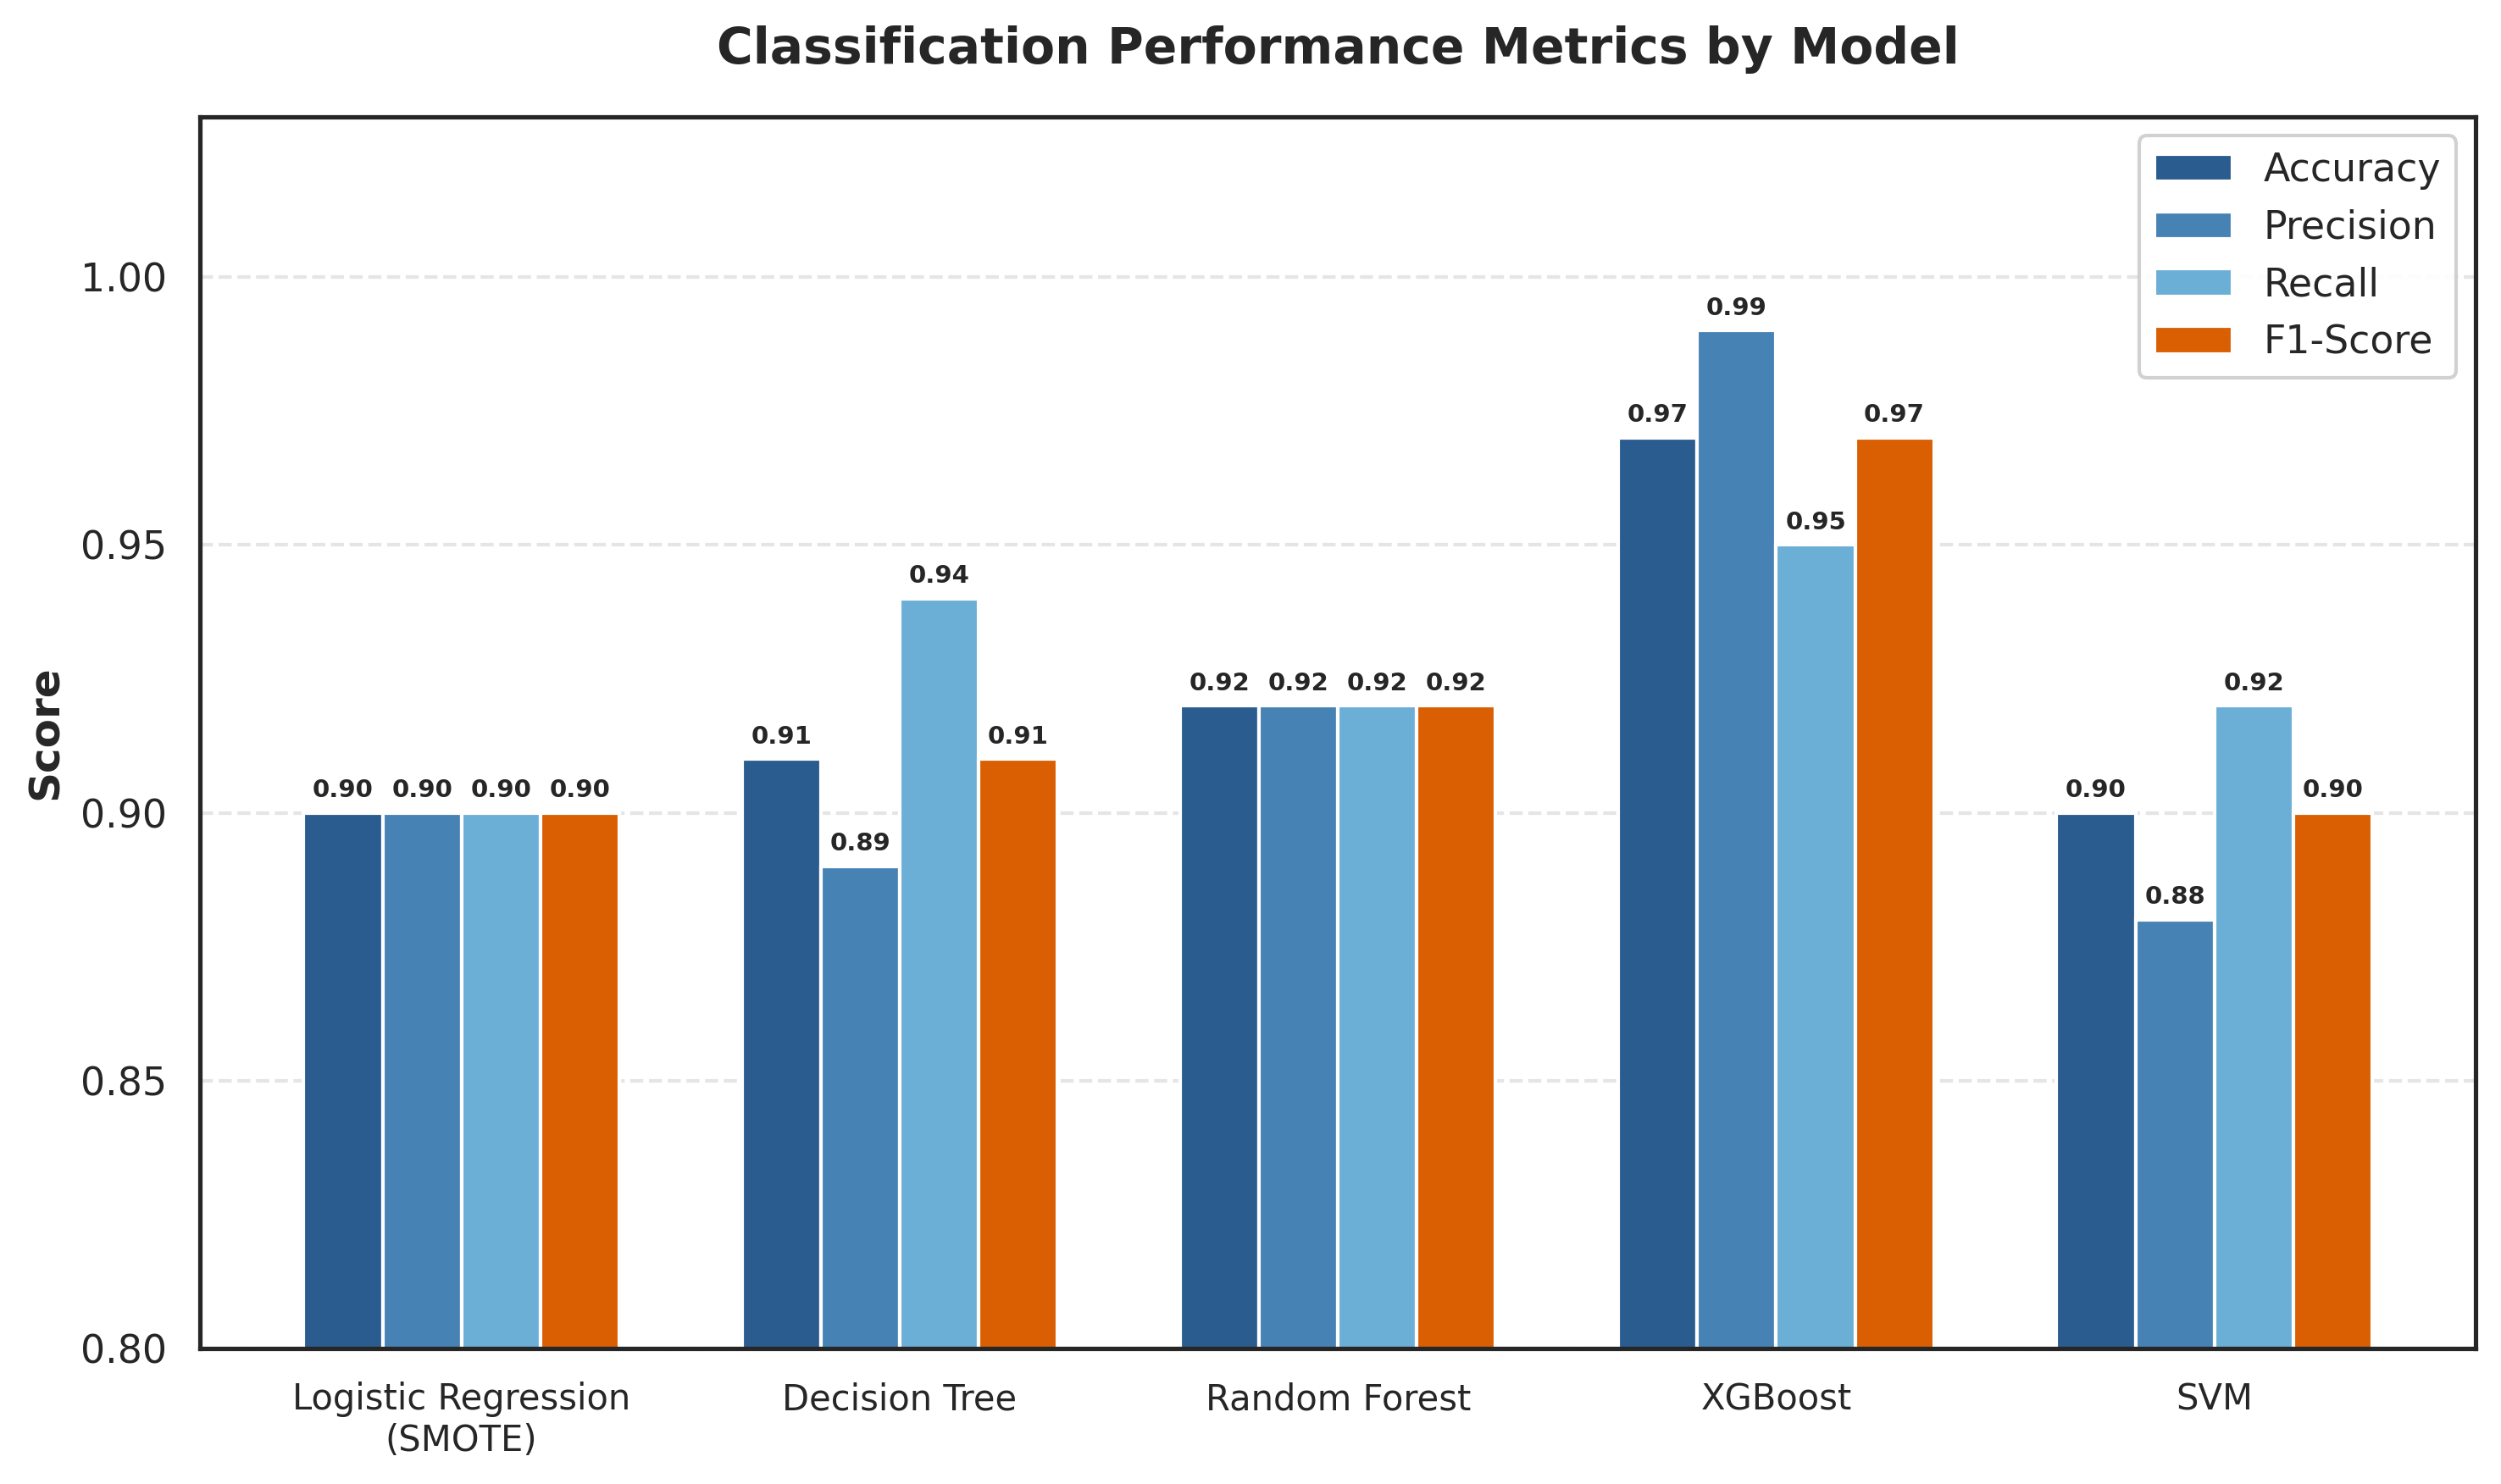

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data setup
models = ['Logistic Regression\n(SMOTE)', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

data = {
    'Accuracy': [0.90, 0.91, 0.92, 0.97, 0.90],
    'Precision': [0.90, 0.89, 0.92, 0.99, 0.88],
    'Recall': [0.90, 0.94, 0.92, 0.95, 0.92],
    'F1-Score': [0.90, 0.91, 0.92, 0.97, 0.90]
}

df = pd.DataFrame(data, index=models)

# Plotting Grouped Bar Chart
x = np.arange(len(models))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

colors = ['#2b5c8f', '#4682b4', '#6baed6', '#d95f02']

for i, metric in enumerate(metrics):
    bars = ax.bar(x + (i - 1.5) * width, df[metric], width, label=metric, color=colors[i])
    # Add labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Classification Performance Metrics by Model', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0.80, 1.03)  # Zoom in slightly to highlight differences
ax.legend(frameon=True, facecolor='white', framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()